In [1]:
import yaml
import glob
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import random
from rdkit.Chem import Draw

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Draw, AllChem
rdBase.DisableLog('rdApp.*')  # RDKitのエラーログを無効化
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.ML.Cluster import Butina

from tdc import Evaluator as tdc_Evaluator

from mol_data import Mol_Data
from evaluator import Evaluator
from evaluator import population_similarity

In [2]:
class Island:

    smi2score = {}

    def __init__(self, path, task):
        self.evaluator = Evaluator(task)
        self.populations = []
        self.num_generation = 0

        self.load(path)

    def load(self,path):
        path = os.path.join(path,'population')
        # 指定されたディレクトリ内で'population_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(path, 'population_*.yaml'))
        if yaml_files == []:
            print("No result files found in {}".format(path))
            return
        self.num_generation = len(yaml_files)

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        # ソートされたファイルリストをループ処理し、YAMLデータを読み込んで結果リストに追加します。
        print("Loading results ...")
        for yaml_file in tqdm(yaml_files):
            with open(yaml_file, 'r', encoding='utf-8') as f:
                datas = yaml.safe_load(f)
                population = []
                for data in datas.values():
                    
                    if data["smi"] not in Island.smi2score:
                        Island.smi2score[data["smi"]] = self.evaluator.score(data["smi"])

                    if "inter_smi" in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"],
                            data["inter_smi"]))
                    if "inter_smi" not in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"]))

                self.populations.append(population)

        print("Loading finished")

In [3]:
class visualizer:
    def __init__(self, islands):
        self.islands = islands
        self.overall_populations = []
        self.overall()
        self.diversity_evaluator = tdc_Evaluator(name="Diversity")

    def overall(self, cutoff=0.3, population_size=100):
        min_generation = min([island.num_generation for island in self.islands.values()])
        for gen in range(min_generation):   
            all_population = []
            overall_population = []
            for name, island in self.islands.items():
                all_population.extend(island.populations[gen])
            clusters = self.cluster_population(all_population,cutoff=cutoff)
            for cluster in clusters:
                overall_population.append(max(cluster))

            overall_population.sort(reverse=True)
            overall_population = overall_population[:population_size]
            self.overall_populations.append(overall_population)

    def population_score(self,populations):
        scores = []
        for population in populations:
            scores.append(np.mean([mlc.score for mlc in population][:10]))
        return scores

    def plot_scoore_shift(self):
        avg_scores_dict = {name: self.population_score(island.populations) for name, island in self.islands.items()}
        avg_scores_dict["Overall"] = self.population_score(self.overall_populations)

        # Plot the avg_scores
        plt.figure(figsize=(10, 6))
        for name, scores in avg_scores_dict.items():
            plt.plot(scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Top-10 Score")
        plt.title("Top-10 Scores per Generation for Each LLM")
        plt.legend()
        plt.show()

    def population_diversity(self,populations):
        scores = []
        for population in populations:
            smis = [mlc.smi for mlc in population]
            scores.append(self.diversity_evaluator(smis))
        return scores

    def plot_diversity_shift(self):
        diversities_dict = {name: self.population_diversity(island.populations) for name, island in self.islands.items()}
        diversities_dict["Overall"] = self.population_diversity(self.overall_populations)
        # Plot the diversities
        plt.figure(figsize=(10, 6))
        for name, diversity_scores in diversities_dict.items():
            plt.plot(diversity_scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Diversity Score")
        plt.title("Diversity Scores per Generation for Each LLM")
        plt.legend()
        plt.show()

    def cluster_population(self, population, cutoff=0.2):
        """
        Perform Butina clustering on a population based on molecular fingerprints.

        Args:
            population (list): A list of Mol_Data objects.
            cutoff (float): Tanimoto similarity cutoff for clustering.

        Returns:
            list: A list of clusters, where each cluster is a list of Mol_Data objects.
        """
        # Generate fingerprints for all molecules in the population
        fps = [AllChem.GetMorganFingerprintAsBitVect(mlc.mol, radius=2) for mlc in population]

        # Calculate pairwise Tanimoto similarities
        n = len(fps)
        dists = []
        for i in range(1, n):
            sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
            dists.extend([1 - sim for sim in sims])  # Convert similarity to distance

        # Perform Butina clustering
        clusters = Butina.ClusterData(dists, nPts=n, distThresh=cutoff, isDistData=True)

        # Map cluster indices to Mol_Data objects
        clustered_population = [[population[idx] for idx in cluster] for cluster in clusters]

        return clustered_population
    
    def draw_molecules(self, mlcs, num=10):
        # Extract RDKit molecule objects from Mol_Data
        mols = [mlc.mol for mlc in mlcs[:num]]
        
        # Draw the molecules
        img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200))
        display(img)

    def plot_population_sim_matrix(self, generation):
        # Calculate the similarity matrix
        island_names = list(self.islands.keys())
        num_islands = len(island_names)
        similarity_matrix = np.zeros((num_islands, num_islands))

        for i in range(num_islands):
            for j in range(num_islands):
                if i <= j:  # Avoid redundant calculations
                    similarity = population_similarity(self.islands[island_names[i]].populations[generation], self.islands[island_names[j]].populations[generation])
                    similarity_matrix[i, j] = similarity
                    similarity_matrix[j, i] = similarity  # Symmetric matrix

        # Plot the similarity matrix as a heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(similarity_matrix, xticklabels=island_names, yticklabels=island_names, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Population Similarity Matrix")
        plt.xlabel("Island")
        plt.ylabel("Island")
        plt.show()

    def visualize_multiple_sets(self, mol_sets_dict, n_components=2, perplexity=30, random_state=42):
        """
        複数の分子集合を受け取り、t-SNEで同一平面上にプロットする関数
        
        Args:
            mol_sets_dict (dict): {"ラベル名": [RDKit Mol objects], ...} の形式
            n_components (int): 圧縮後の次元数（通常2）
            perplexity (int): t-SNEの近傍点パラメータ（データ数に合わせて調整が必要）
            random_state (int): 再現性のための乱数シード
        """
        
        # --- 1. フィンガープリントへの変換と結合 ---
        all_fps = []        # 全てのフィンガープリント（t-SNE学習用）
        dataset_names = []  # プロット時のループ用
        dataset_counts = {} # 各セットのデータ数を記録（後で分割するため）
        
        print("フィンガープリント生成中...")
        
        for name, mols in mol_sets_dict.items():
            fps = []
            for mol in mols:
                if mol is not None:
                    try:
                        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
                        arr = np.zeros((1,))
                        DataStructs.ConvertToNumpyArray(fp, arr)
                        fps.append(arr)
                    except:
                        pass
            
            if len(fps) > 0:
                np_fps = np.array(fps)
                all_fps.append(np_fps)
                dataset_names.append(name)
                dataset_counts[name] = len(np_fps) # 個数を記録
                print(f"  - {name}: {len(np_fps)} molecules")
            else:
                print(f"  - {name}: 有効な分子がありません (スキップ)")

        if not all_fps:
            print("プロット可能なデータがありません。")
            return

        # 全データを縦に結合 (Stack)
        X_total = np.vstack(all_fps)
        n_samples = X_total.shape[0]

        # --- 2. t-SNEの実行 ---
        # Perplexityの自動調整（データ数が少ない場合の安全策）
        if n_samples <= perplexity:
            perplexity = max(1, n_samples - 1)
            print(f"警告: データ数が少なすぎます。Perplexityを {perplexity} に調整しました。")

        print(f"t-SNE計算中... (Total data shape: {X_total.shape})")
        print("※データ数が多い場合、PCAより時間がかかります...")
        
        # init='pca' にすると初期配置がPCAベースになり、結果が安定しやすくなります
        tsne = TSNE(n_components=n_components, 
                    perplexity=perplexity, 
                    random_state=random_state,
                    init='pca', 
                    learning_rate='auto')
        
        X_embedded = tsne.fit_transform(X_total)

        # --- 3. プロット ---
        plt.figure(figsize=(10, 8))
        
        # 色の準備
        colors = cm.get_cmap('tab10', len(dataset_names)) 
        
        current_idx = 0 # データスライスの開始位置
        
        for i, name in enumerate(dataset_names):
            count = dataset_counts[name]
            
            # 結合された結果から、このデータセットに該当する部分を抜き出す
            X_subset = X_embedded[current_idx : current_idx + count]
            current_idx += count # 次の開始位置を更新
            
            # 散布図
            plt.scatter(X_subset[:, 0], X_subset[:, 1], 
                        alpha=0.6,
                        label=name,
                        color=colors(i),
                        s=40,
                        edgecolors='white', linewidth=0.5) 

        # グラフの装飾
        plt.title('Chemical Space Distribution (t-SNE)', fontsize=14)
        plt.xlabel('t-SNE dimension 1', fontsize=12)
        plt.ylabel('t-SNE dimension 2', fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

In [4]:
class Multi_Visualizer():
    def __init__(self, visualizers):
        self.visualizers = visualizers
        self.diversity_evaluator = tdc_Evaluator(name="Diversity")

    def population_score(self,populations):
        scores = []
        for population in populations:
            scores.append(np.mean([mlc.score for mlc in population][:10]))
        return scores

    def plot_scoore_shift(self):
        avg_scores_dict = {name: self.population_score(visualizer.overall_populations) for name, visualizer in self.visualizers.items()}

        # Plot the avg_scores
        plt.figure(figsize=(10, 6))
        for name, scores in avg_scores_dict.items():
            plt.plot(scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Top-10 Score")
        plt.title("Top-10 Scores per Generation for Immigration type")
        plt.legend()
        plt.show()

    def population_diversity(self,populations):
        scores = []
        for population in populations:
            smis = [mlc.smi for mlc in population]
            scores.append(self.diversity_evaluator(smis))
        return scores

    def plot_diversity_shift(self):
        diversities_dict = {name: self.population_diversity(visualizer.overall_populations) for name, visualizer in self.visualizers.items()}
        # Plot the diversities
        plt.figure(figsize=(10, 6))
        for name, diversity_scores in diversities_dict.items():
            plt.plot(diversity_scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Diversity Score")
        plt.title("Diversity Scores per Generation for Each Immigration type")
        plt.legend()
        plt.show()

    

In [5]:
cluster = visualizer({
    "GPT-OSS:20B": Island("results/cluster_long/GPT","JNK3"),
    "Biot5": Island("results/cluster_long/BioT5","JNK3"),
    "Gemma2:9B": Island("results/cluster_long/Gemma","JNK3"),
    "Qwen3:8B": Island("results/cluster_long/Qwen3","JNK3")
})

Found local copy...


Loading results ...


100%|██████████| 100/100 [00:56<00:00,  1.77it/s]


Loading finished
Loading results ...


100%|██████████| 100/100 [00:15<00:00,  6.56it/s]


Loading finished
Loading results ...


100%|██████████| 100/100 [00:41<00:00,  2.41it/s]


Loading finished
Loading results ...


100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


Loading finished


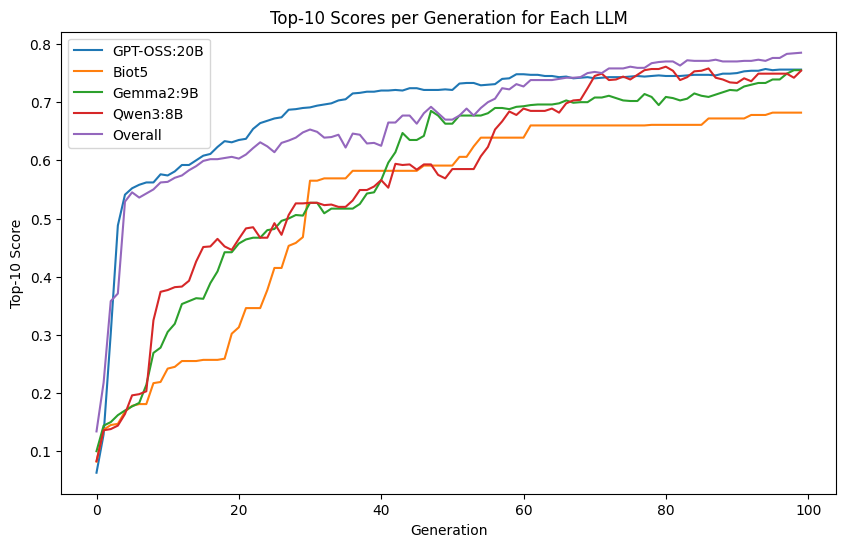

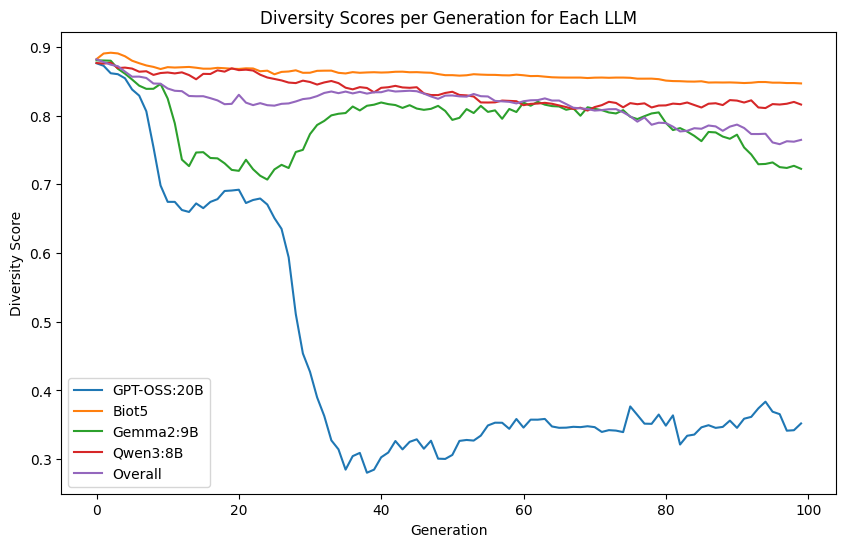

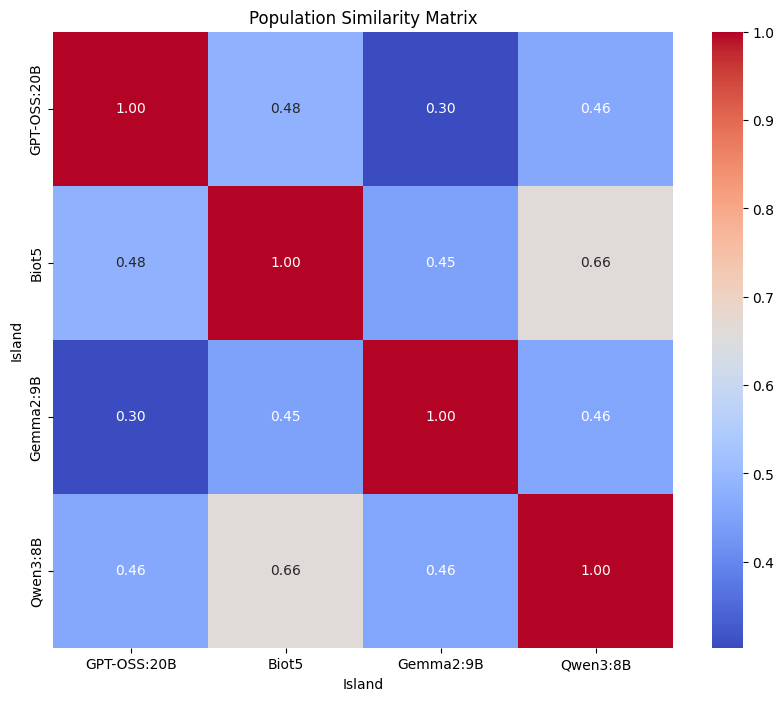

In [7]:
cluster.plot_scoore_shift()
cluster.plot_diversity_shift()
cluster.plot_population_sim_matrix(generation=-1)
cluster

In [ ]:
cluster = visualizer({
    "GPT-OSS:20B": Island("results/cluster_novelty/GPT","JNK3"),
    "Biot5": Island("results/cluster_novelty/BioT5","JNK3"),
    "Gemma2:9B": Island("results/cluster_novelty/Gemma","JNK3"),
    "Qwen3:8B": Island("results/cluster_novelty/Qwen3","JNK3")
})


no_imm = visualizer({
    "GPT-OSS:20B": Island("results/no_immigration/GPT","JNK3"),
    "Biot5": Island("results/no_immigration/BioT5","JNK3"),
    "Gemma2:9B": Island("results/no_immigration/Gemma","JNK3"),
    "Qwen3:8B": Island("results/no_immigration/Qwen3","JNK3")
})

random = visualizer({
    "GPT-OSS:20B": Island("results/random/GPT","JNK3"),
    "Biot5": Island("results/random/BioT5","JNK3"),
    "Gemma2:9B": Island("results/random/Gemma","JNK3"),
    "Qwen3:8B": Island("results/random/Qwen3","JNK3")
})

multi_visualizer = Multi_Visualizer({
    "cluster_novelty": cluster,
    "No_immigration": no_imm,
    "Random": random
})

Loading results ...


100%|██████████| 30/30 [00:40<00:00,  1.36s/it]


Loading finished
Loading results ...


100%|██████████| 30/30 [00:09<00:00,  3.04it/s]


Loading finished
Loading results ...


...

Loading finished
Loading results ...


100%|██████████| 30/30 [00:10<00:00,  2.75it/s]


Loading finished
Loading results ...


100%|██████████| 30/30 [00:07<00:00,  3.81it/s]


Loading finished


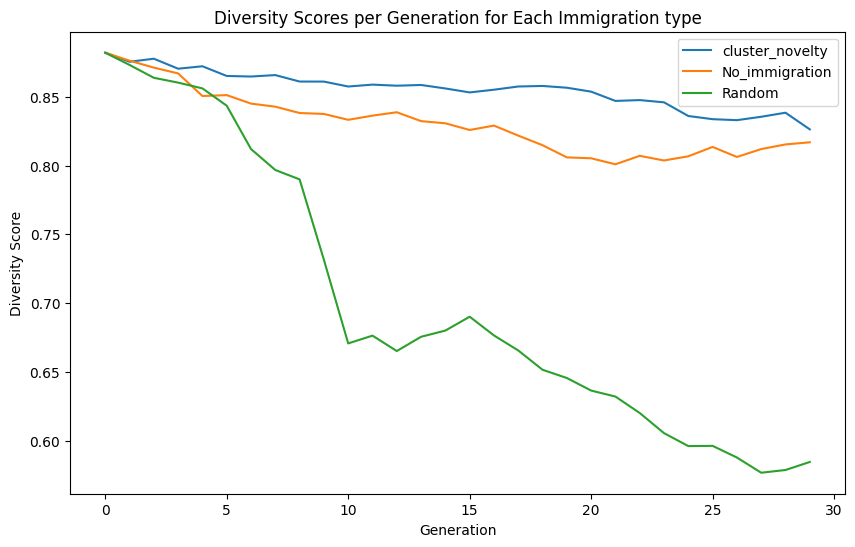

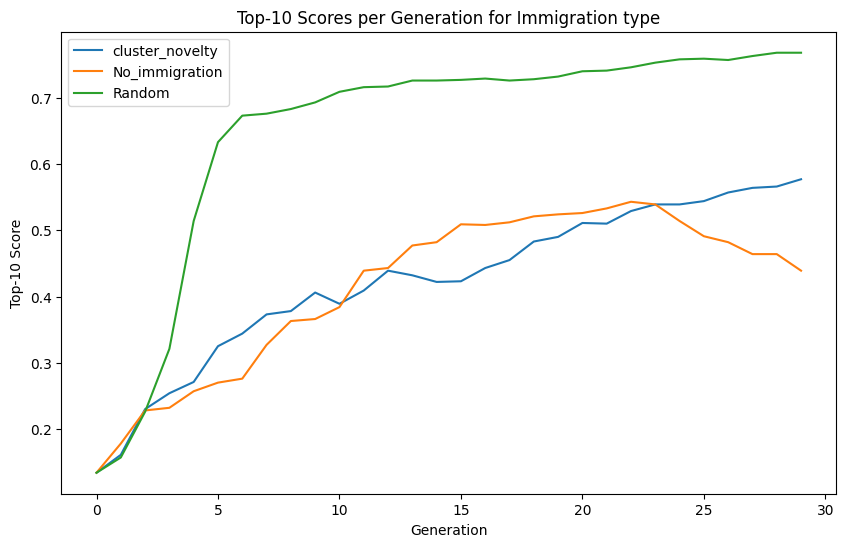

In [ ]:
multi_visualizer.plot_diversity_shift()
multi_visualizer.plot_scoore_shift()

In [ ]:
random1.plot_scoore_shift()
random1.plot_diversity_shift()
random1.plot_population_sim_matrix(generation=-1)

NameError: name 'random1' is not defined

フィンガープリント生成中...
  - Initial: 100 molecules
  - GPT-OSS:20B: 100 molecules
  - Biot5: 100 molecules
  - Gemma2:9B: 100 molecules
  - Qwen3:8B: 97 molecules
t-SNE計算中... (Total data shape: (497, 2048))
※データ数が多い場合、PCAより時間がかかります...


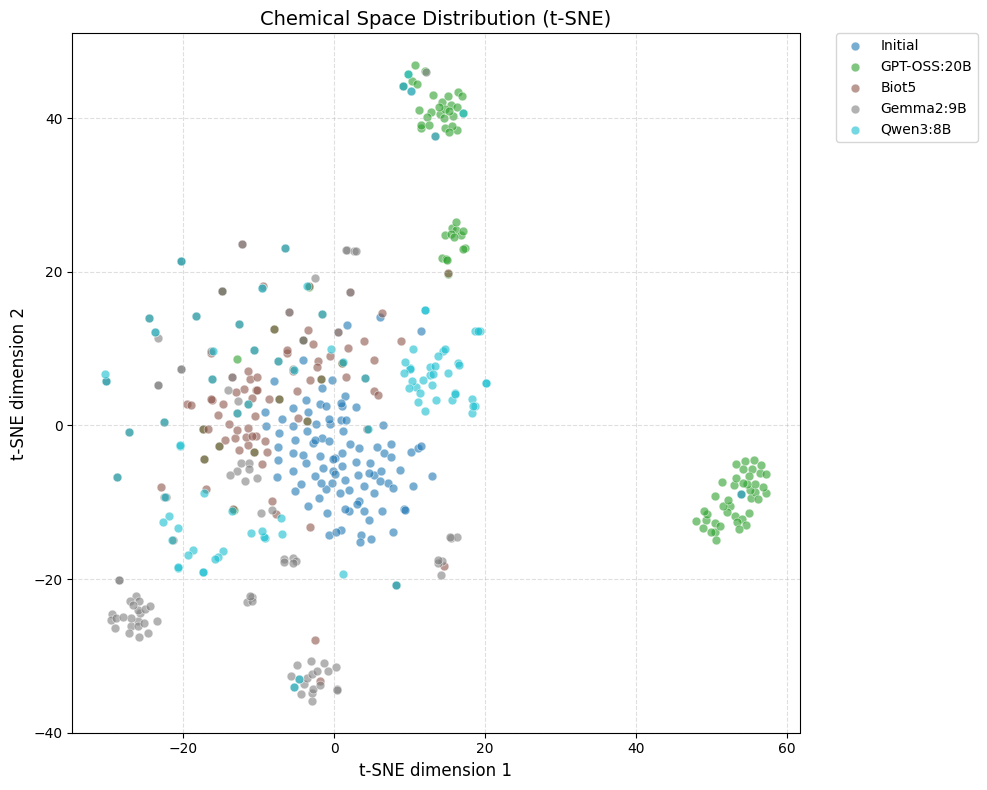

In [ ]:
random1.visualize_multiple_sets({
    "Initial": [mlc.mol for mlc in random1.islands["GPT-OSS:20B"].populations[0]],
    "GPT-OSS:20B": [mlc.mol for mlc in random1.islands["GPT-OSS:20B"].populations[-1]],
    "Biot5": [mlc.mol for mlc in random1.islands["Biot5"].populations[-1]],
    "Gemma2:9B": [mlc.mol for mlc in random1.islands["Gemma2:9B"].populations[-1]],
    "Qwen3:8B": [mlc.mol for mlc in random1.islands["Qwen3:8B"].populations[-1]]})